<a href="https://colab.research.google.com/github/vashgarvit014/CelebalAssignment/blob/main/Week3_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Required Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


Loading the Dataset

In [ ]:
df = pd.read_csv("Country-data.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (167, 10)


In [ ]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [ ]:
df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [ ]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


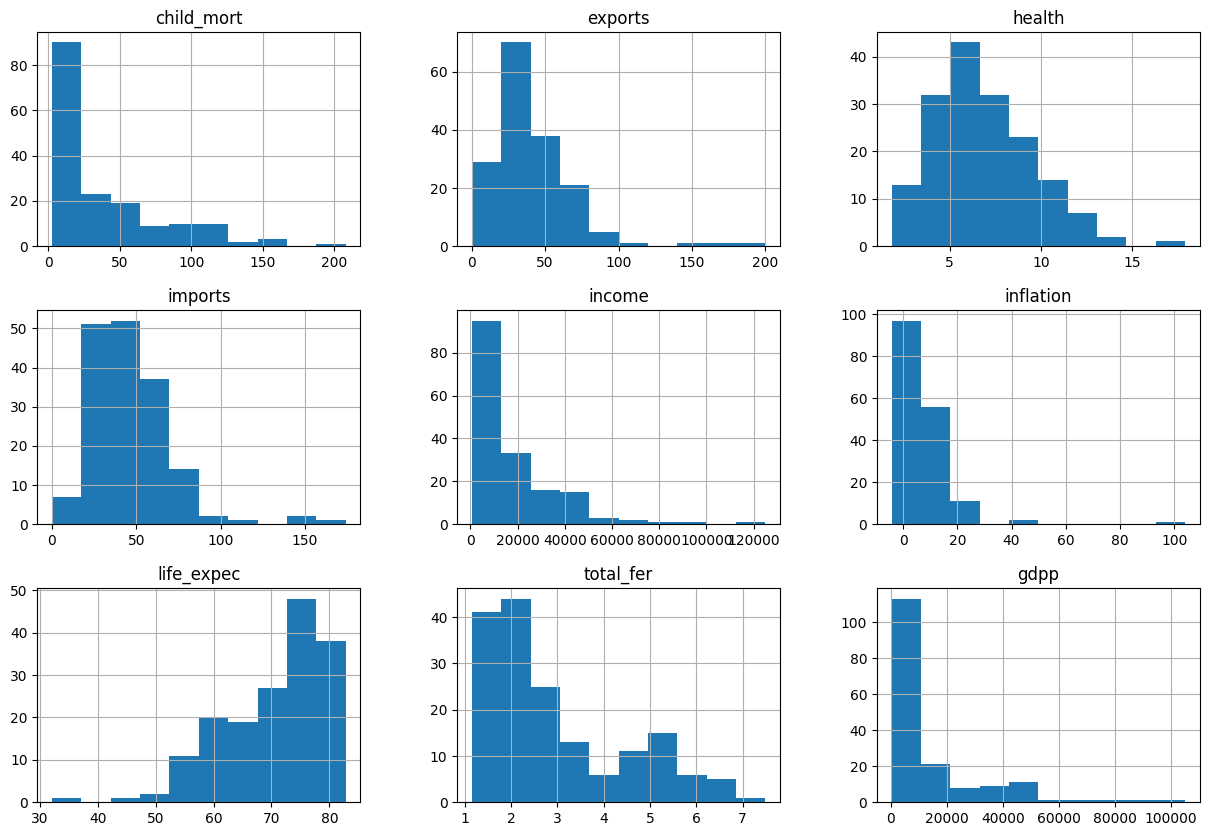

In [ ]:
df.hist(figsize=(15,10))
plt.show()

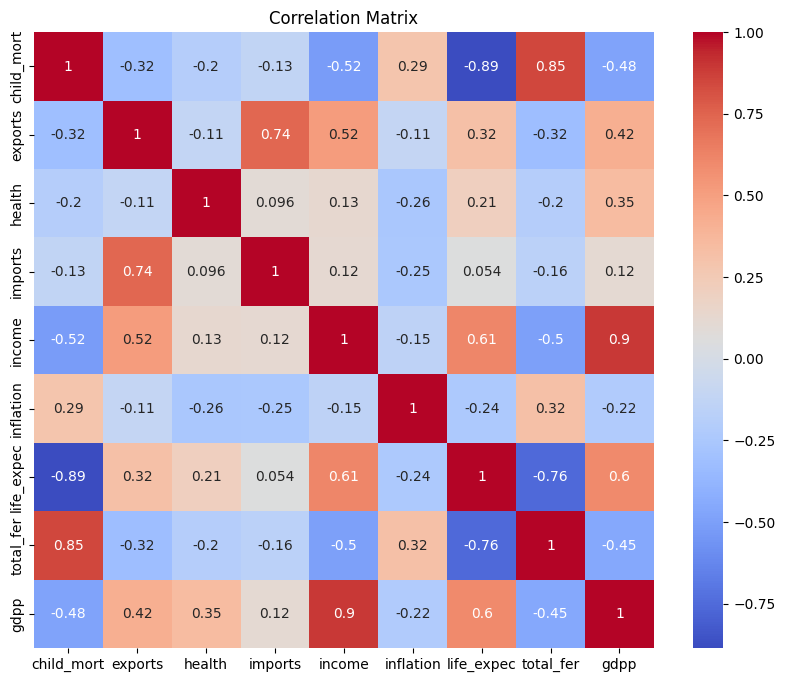

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.drop("country", axis=1).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
X = df.drop("country", axis=1)

print("Shape of numerical dataset:", X.shape)

Shape of numerical dataset: (167, 9)


Data Preprocessing

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data scaled successfully!")

Data scaled successfully!


In [ ]:
pd.DataFrame(X_scaled, columns=X.columns).describe().round(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,-0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.89,-1.50,-1.83,-1.94,-0.86,-1.14,-4.34,-1.19,-0.70
25%,-0.75,-0.63,-0.69,-0.69,-0.72,-0.57,-0.59,-0.76,-0.64
50%,-0.47,-0.22,-0.18,-0.15,-0.37,-0.23,0.29,-0.36,-0.45
75%,0.59,0.37,0.65,0.49,0.29,0.28,0.70,0.62,0.06
max,4.22,5.81,4.05,5.27,5.61,9.13,1.38,3.01,5.04


In [ ]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

print("WCSS values calculated successfully!")

WCSS values calculated successfully!


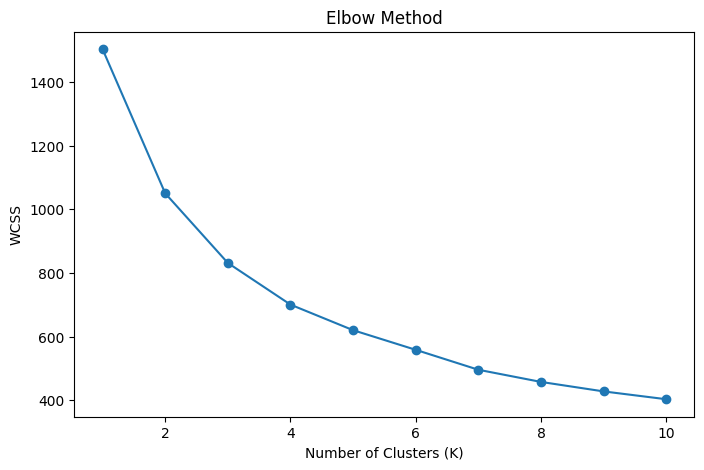

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

kmeans_labels = kmeans.fit_predict(X_scaled)

print("K-Means clustering completed!")

K-Means clustering completed!


In [ ]:
df["KMeans_Cluster"] = kmeans_labels

print("Cluster labels added successfully!")

Cluster labels added successfully!


In [ ]:
df["KMeans_Cluster"].value_counts()

,count
KMeans_Cluster,
2,84
1,47
0,36


In [ ]:
cluster_summary = df.groupby("KMeans_Cluster").mean(numeric_only=True)

cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
KMeans_Cluster,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381


In [ ]:
cluster_names = {
    0: "Developed",
    1: "Developing",
    2: "Emerging"
}

df["Country_Category"] = df["KMeans_Cluster"].map(cluster_names)

print("Cluster names assigned successfully!")

Cluster names assigned successfully!


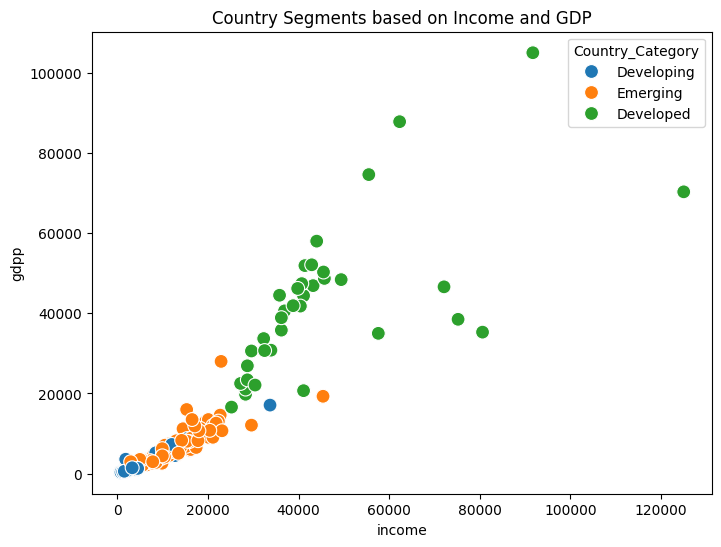

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="income",
    y="gdpp",
    hue="Country_Category",
    s=100
)

plt.title("Country Segments based on Income and GDP")
plt.show()

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PCA completed successfully!")

PCA completed successfully!


In [ ]:
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

pca_df["Cluster"] = df["Country_Category"]

pca_df.head()

,PC1,PC2,Cluster
0,-2.913025,0.095621,Developing
1,0.429911,-0.588156,Emerging
2,-0.285225,-0.455174,Emerging
3,-2.932423,1.695555,Developing
4,1.033576,0.136659,Emerging


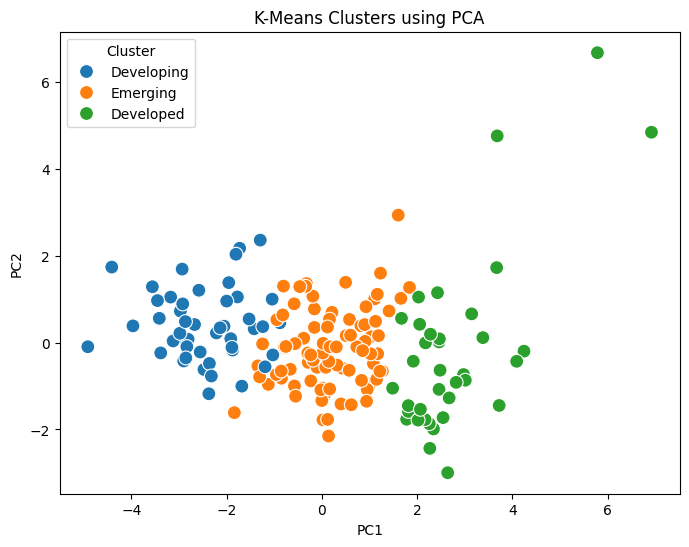

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    s=100
)

plt.title("K-Means Clusters using PCA")
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.2, min_samples=5)

dbscan_labels = dbscan.fit_predict(X_scaled)

print("DBSCAN clustering completed!")

DBSCAN clustering completed!


In [ ]:
pd.Series(dbscan_labels).value_counts()

,count
1,75
-1,53
0,21
2,18


In [ ]:
df["DBSCAN_Cluster"] = dbscan_labels

print("DBSCAN labels added successfully!")

DBSCAN labels added successfully!


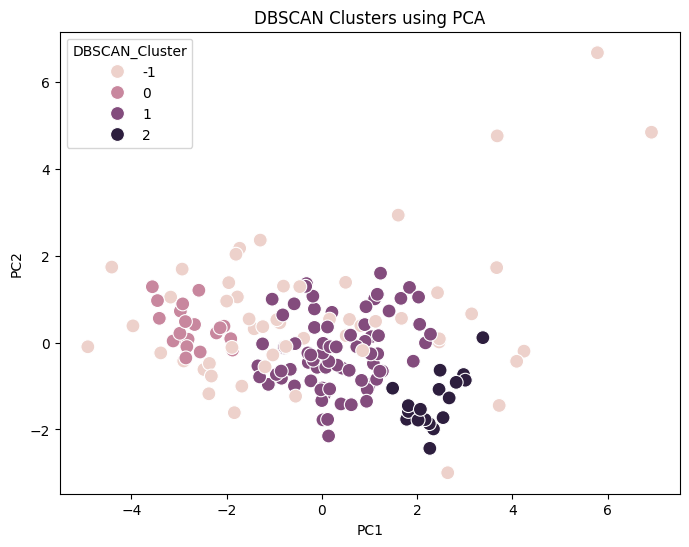

In [ ]:
pca_df["DBSCAN_Cluster"] = dbscan_labels

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="DBSCAN_Cluster",
    s=100
)

plt.title("DBSCAN Clusters using PCA")
plt.show()

In [ ]:
pd.Series(dbscan_labels).value_counts()

,count
1,75
-1,53
0,21
2,18


In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, kmeans_labels)

print("Silhouette Score:", round(score, 3))

Silhouette Score: 0.283


In [ ]:
valid_points = dbscan_labels != -1

dbscan_score = silhouette_score(
    X_scaled[valid_points],
    dbscan_labels[valid_points]
)

print("DBSCAN Silhouette Score:", round(dbscan_score, 3))

DBSCAN Silhouette Score: 0.385


In [ ]:
X = df.drop(
    ["country", "KMeans_Cluster", "Country_Category", "DBSCAN_Cluster"],
    axis=1
)

y = df["KMeans_Cluster"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (167, 9)
Target Shape: (167,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (133, 9)
Testing Set: (34, 9)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [ ]:
from sklearn.metrics import accuracy_score

y_pred_rf = rf.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", round(accuracy_rf, 3))

Random Forest Accuracy: 0.971


In [ ]:
print("Training Accuracy:", rf.score(X_train, y_train))
print("Testing Accuracy:", rf.score(X_test, y_test))

Training Accuracy: 1.0
Testing Accuracy: 0.9705882352941176


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.86      1.00      0.92         6
           2       1.00      0.95      0.97        20

    accuracy                           0.97        34
   macro avg       0.95      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



The Random Forest classifier achieved an accuracy of 97.1% on the test set. The model demonstrated excellent precision, recall, and F1-scores across all clusters, indicating that the generated country segments were highly distinguishable.

In [ ]:
import xgboost as xgb

print("XGBoost imported successfully!")

XGBoost imported successfully!


In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train, y_train)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [ ]:
from sklearn.metrics import accuracy_score

y_pred_xgb = xgb_model.predict(X_test)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:", round(accuracy_xgb, 3))

XGBoost Accuracy: 0.971


In [ ]:
results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [accuracy_rf, accuracy_xgb]
})

results

,Model,Accuracy
0,Random Forest,0.970588
1,XGBoost,0.970588


In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,child_mort,0.276790
8,gdpp,0.194674
4,income,0.167519
6,life_expec,0.157759
7,total_fer,0.141250
2,health,0.024614
5,inflation,0.015699
1,exports,0.013360
3,imports,0.008336


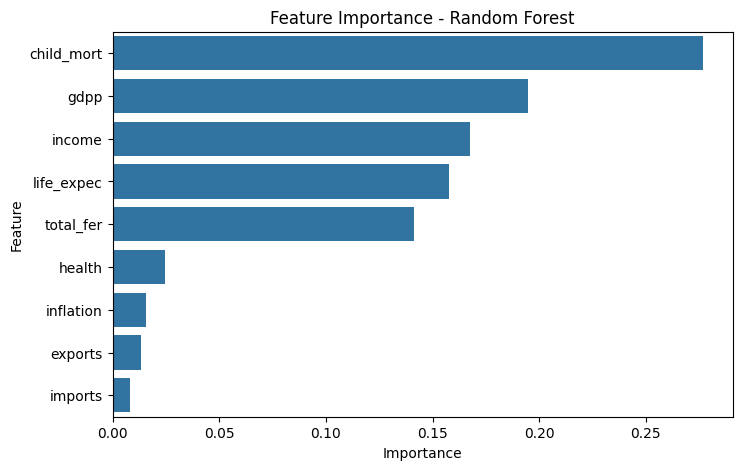

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Random Forest")
plt.show()

Customer Intelligence System - Observations

1. The dataset had 167 countries with 10 features and was clean (no missing values).
2. All features were scaled before applying clustering.
3. K-Means (K=3) grouped countries into 3 segments: Developed, Emerging, Developing.
4. DBSCAN also used but gave many noise points, so it was less useful here.
5. Random Forest and XGBoost were used to predict these clusters.
6. Both models gave around 97% accuracy.
7. Child mortality was the most important factor in deciding clusters.

Conclusion:
Countries are mainly grouped based on income, GDP, and health-related factors.